<a href="https://colab.research.google.com/github/bitsteller/dataanalys-for-kollektivtrafik/blob/main/Kod/Laboration%203/Uppgift3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboration 3 – Uppgift 3

Den här uppgiften fokuserar på visualisering med *plotnine*. Uppgiften ska ta ungefär 15min.

## Jobba så här
1. Kör första cellen för att läsa in data.
1. Kör exempelcellen i varje avsnitt.
2. Fyll i övningscellen.
3. Tolka resultatet.

Ändra bara i cellerna där det står *Övning*.

In [16]:
#Kör denna cell först för att läsa in data.

import polars as pl
from plotnine import ggplot, aes, geom_col, labs, theme_minimal, geom_boxplot, geom_point, coord_flip, theme_set

theme_set(theme_minimal())

BASE_URL = "https://raw.githubusercontent.com/bitsteller/dataanalys-for-kollektivtrafik/main/Data/Laboration%203"
TRAINS_URL = f"{BASE_URL}/trains.parquet"

trains = pl.read_parquet(TRAINS_URL)

## 1) Stapeldiagram

Vi räknar antal observationer per timme och visualiserar med staplar.

- `ggplot()`: startar en ny plot
- `aes()`: anger vilken kolumn som ska plottas på varje axel
- `geom_col()`: ritar stapeldiagram där stapelhöjd kommer från ett y-värde.


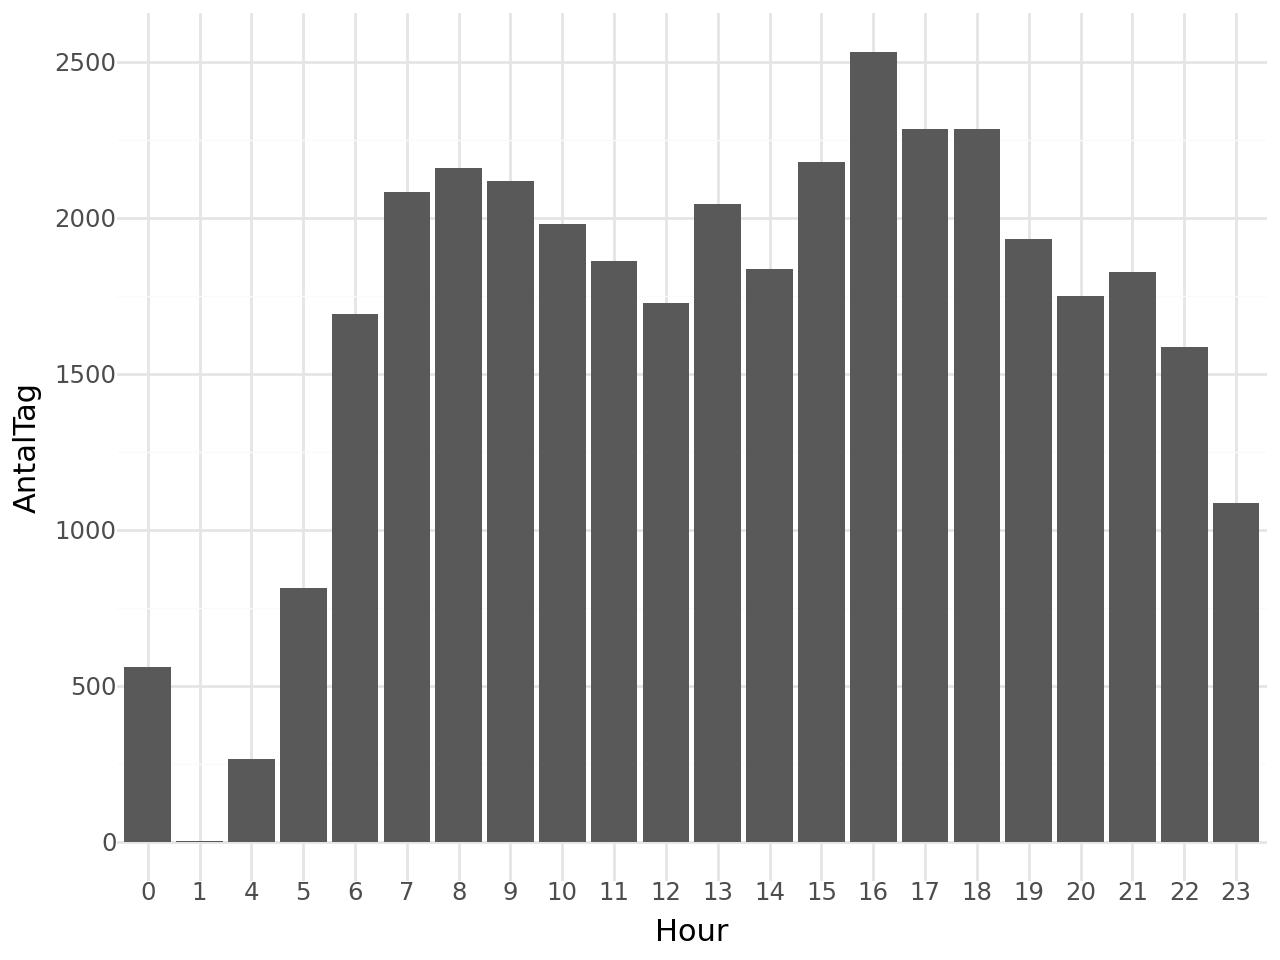

In [17]:
per_product = (
    trains.group_by("Hour")
    .agg(pl.len().alias("AntalTag"))
    .sort("Hour")
)

plot_per_day = (
    ggplot(per_product, aes(x="Hour", y="AntalTag"))
    + geom_col()
)
plot_per_day


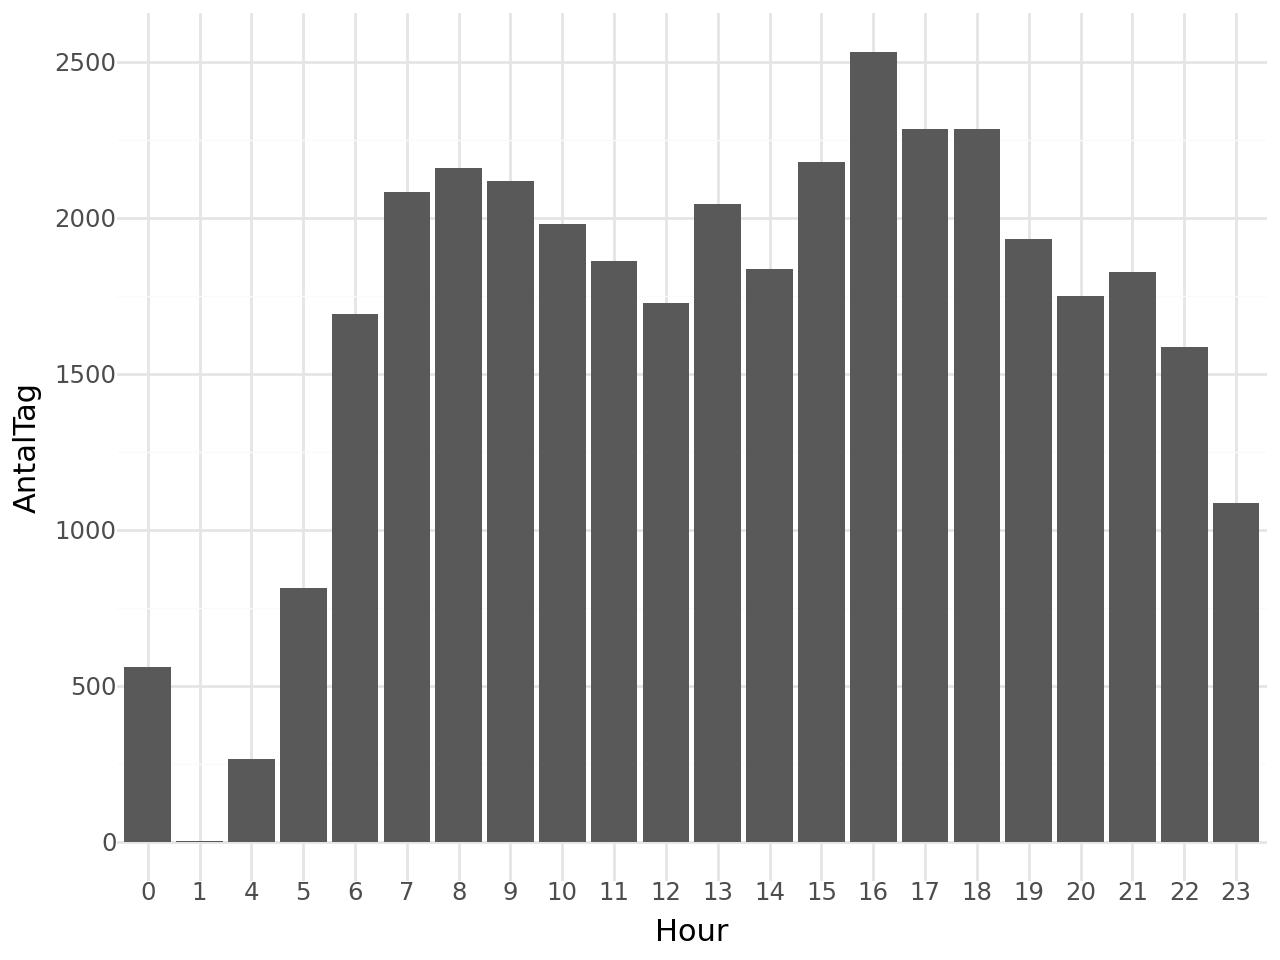

In [18]:
#Testa att ändra diagrammet genom att:
# - Lägga till färg för tågtypen genom att lägga till `fill=ProductName"`` i aes()
# - Lägg till en titel genom att lägga till `labs(title="Antal tåg per produkt")` i ggplot()

per_product = (
    trains.group_by("ProductName", "Hour")
    .agg(pl.len().alias("AntalTag"))
    .sort("Hour")
)

plot_per_day = (
    ggplot(per_product, aes(x="Hour", y="AntalTag"))
    + geom_col()
)
plot_per_day


## 2) Boxplot

Vi undersöker fördelningen av den faktiska uppehållstiden `ActualDwellTime` per tågtyp med en boxplot.

- `drop_nulls()`: tar bort rader med saknade värden.
- `geom_boxplot()`: visar median, kvartiler som ett lådagram, `outlier_shape=''` gör att outliers inte visas som punkter.
- `coord_flip()`: byter plats på x och y-axel


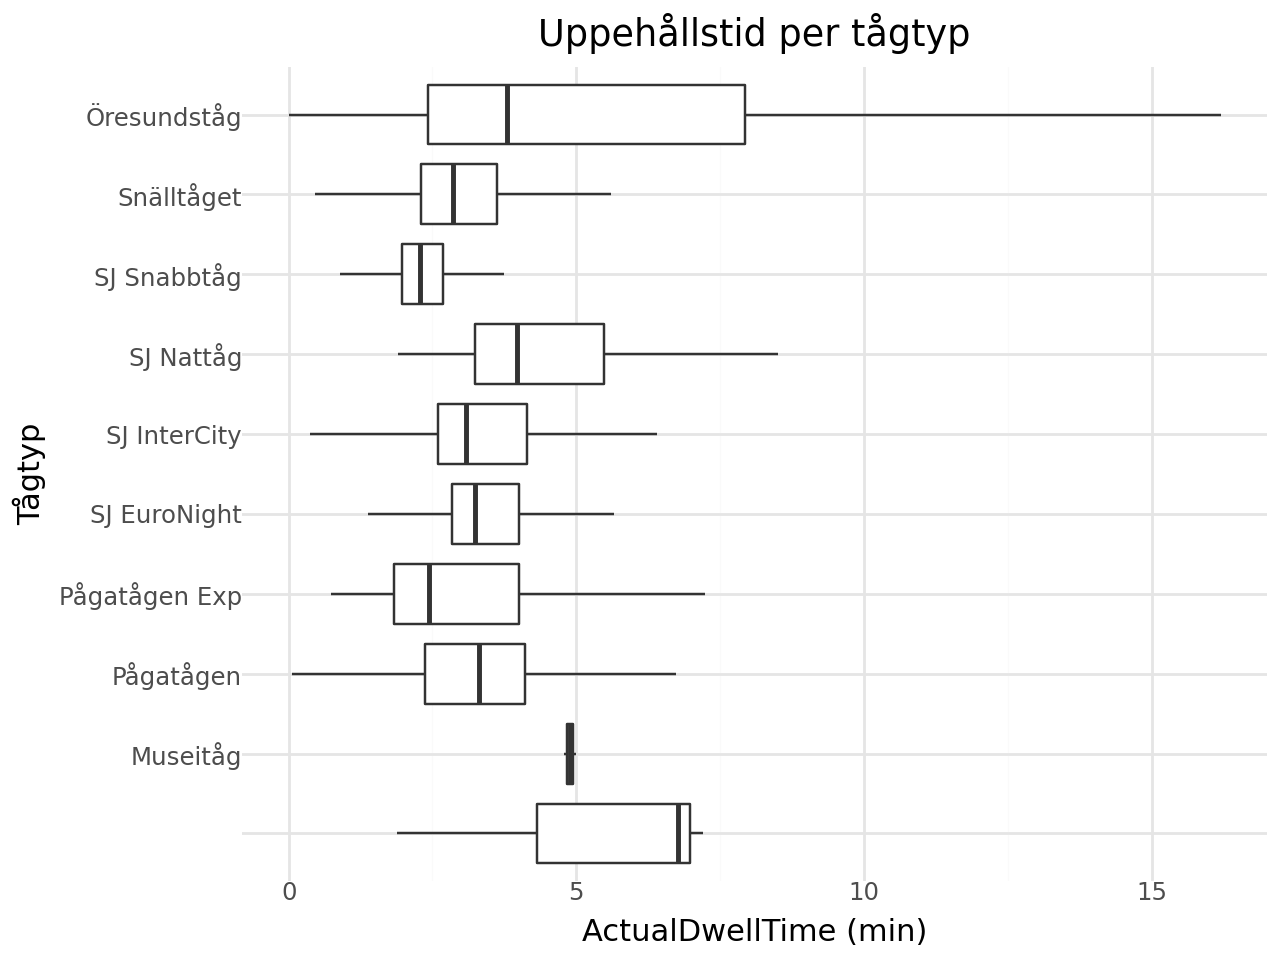

In [19]:
dwelltime = trains.select(["ProductName", "ActualDwellTime"]).drop_nulls()

plot_box = (
    ggplot(dwelltime, aes(x="ProductName", y="ActualDwellTime"))
    + geom_boxplot(outlier_shape='')
    + labs(title="Uppehållstid per tågtyp", x="Tågtyp", y="ActualDwellTime (min)")
    + coord_flip()
)
plot_box


In [20]:
# Övning: Skapa ett liknande diagram för att undersöka uppehållstiden per destination (`ToLocationSignature`) istället.
# Börja med att kopiera koden i cellen ovan.
# Notera att destinationer anges som trafikplatssignaturer, t.ex. Av för Alvesta.





In [21]:
# Bonusövning: Kolla med trains.columns vilka fler kolumner det finns.
# Testa ytterligare en kolumn som kan vara intressant att titta på som boxplot.

# Bonus) Punktdiagram

Vi kan även skapa punktdiagram. Kom ihåg riktlinjerna för visualisering. Är det många punkter på samma ställe kan vi använda transparans för att tydligöra vart det finns många observationer. Detta kan göras genom att lägga till `alpha=0.01` i `geom_point()`.

* `geom_point()` skapar ett punktdiagram





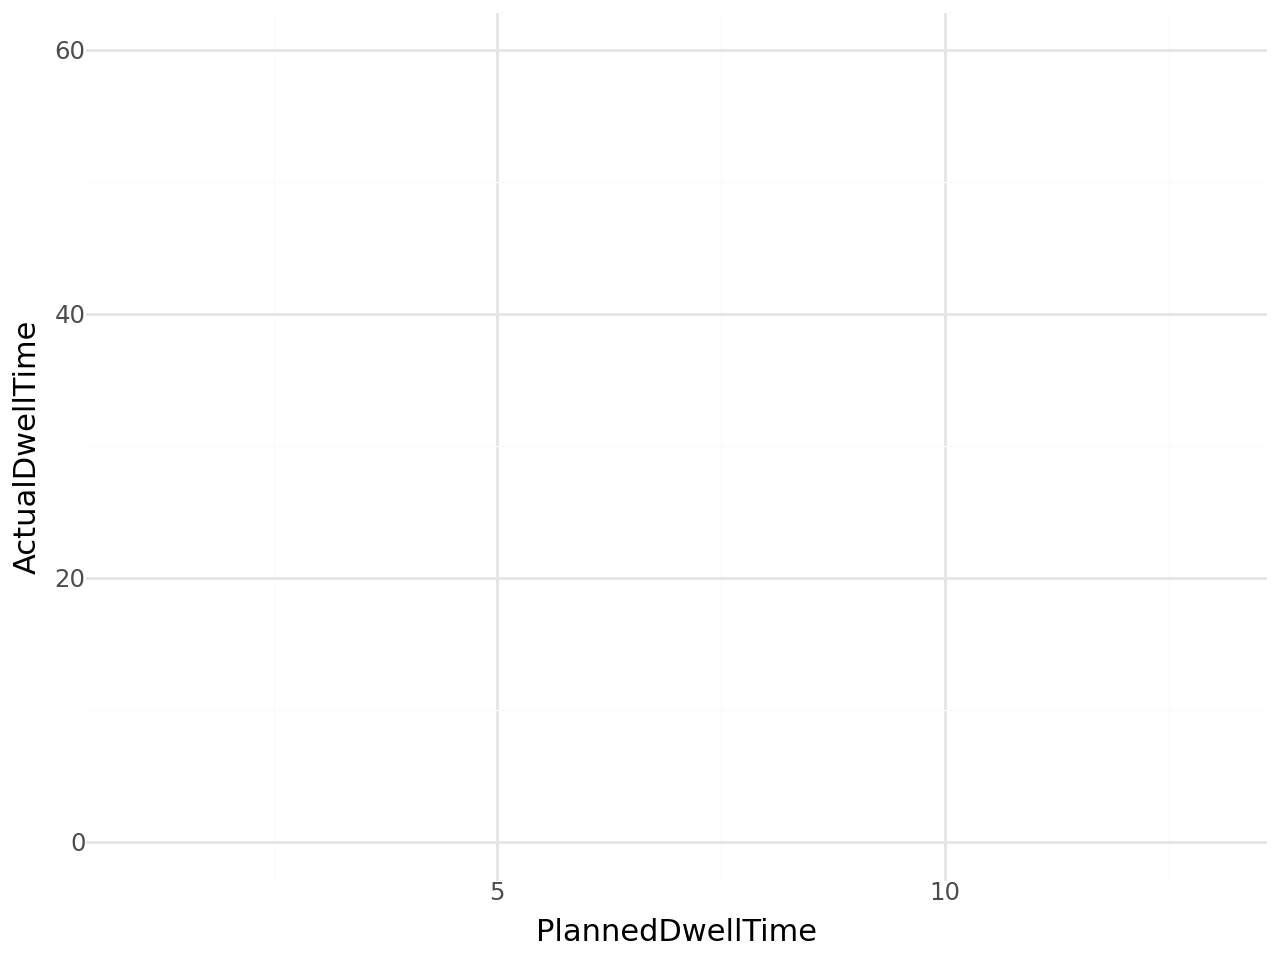

In [22]:
#Övning: Skapa ett punktdiagram
plot_dwell = (
    ggplot(trains, aes(x="PlannedDwellTime", y="ActualDwellTime"))
    #Lägg till kod här
)
plot_dwell